In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [4]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted!")

Mounted at /content/drive
✅ Google Drive mounted!


In [5]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = '/content/drive/MyDrive/processed_data/' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [6]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [7]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from /content/drive/MyDrive/processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [8]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(model, train_loader, val_loader, epochs, lr=0.001, weight_decay=0, model_name='model'):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(epochs):
        # training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # validation phase
        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss_sum += loss.item() * X_batch.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == y_batch).sum().item()
                val_total += y_batch.size(0)

        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'{model_name}_best.pth')

        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1}/{epochs}] '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}')

    # load best weights back
    model.load_state_dict(torch.load(f'{model_name}_best.pth'))
    print(f'\nBest Val Accuracy for {model_name}: {best_val_acc:.4f}')
    return history


def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss'); ax1.legend(); ax1.grid(True)

    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy'); ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    plt.show()


## Part A: The Pancake (Wide & Shallow)
- 2 hidden layers, 1024 neurons each
- Hypothesis: Can raw width (memorization power) solve the problem?

Pancake parameters: 1,868,815
Epoch [1/25] Train Loss: 1.1599 | Train Acc: 0.6174 | Val Loss: 0.9565 | Val Acc: 0.6867 | LR: 0.001000
Epoch [2/25] Train Loss: 0.8611 | Train Acc: 0.7166 | Val Loss: 0.8207 | Val Acc: 0.7272 | LR: 0.001000
Epoch [3/25] Train Loss: 0.7455 | Train Acc: 0.7542 | Val Loss: 0.7938 | Val Acc: 0.7459 | LR: 0.001000
Epoch [4/25] Train Loss: 0.6561 | Train Acc: 0.7807 | Val Loss: 0.7579 | Val Acc: 0.7542 | LR: 0.001000
Epoch [5/25] Train Loss: 0.5874 | Train Acc: 0.8022 | Val Loss: 0.7333 | Val Acc: 0.7633 | LR: 0.001000
Epoch [6/25] Train Loss: 0.5310 | Train Acc: 0.8183 | Val Loss: 0.7253 | Val Acc: 0.7663 | LR: 0.001000
Epoch [7/25] Train Loss: 0.4827 | Train Acc: 0.8334 | Val Loss: 0.7459 | Val Acc: 0.7729 | LR: 0.001000
Epoch [8/25] Train Loss: 0.4392 | Train Acc: 0.8469 | Val Loss: 0.7654 | Val Acc: 0.7672 | LR: 0.001000
Epoch [9/25] Train Loss: 0.3974 | Train Acc: 0.8582 | Val Loss: 0.8014 | Val Acc: 0.7638 | LR: 0.001000
Epoch [10/25] Train Loss: 0.3657 |

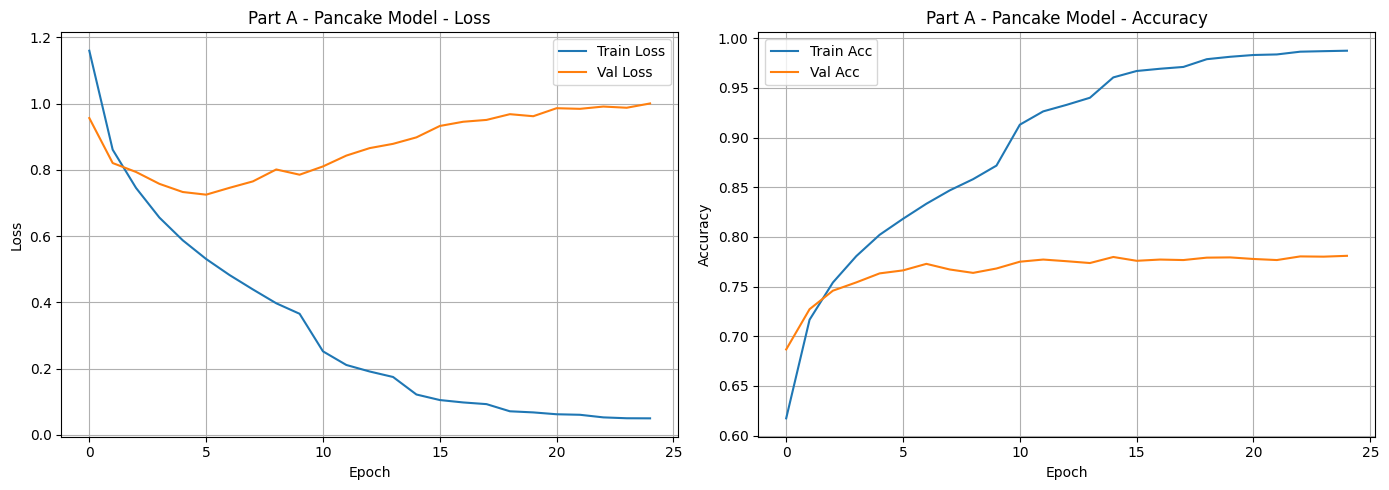

In [7]:
# ==========================================
# PART A: PANCAKE MODEL
# ==========================================

class PancakeMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(PancakeMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, num_classes)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.dropout(torch.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

pancake = PancakeMLP()
pancake_params = count_params(pancake)
print(f'Pancake parameters: {pancake_params:,}')

# use the loaders already created in cell 3
pancake_history = train_model(
    pancake, train_loader, val_loader,
    epochs=25, lr=0.001, weight_decay=1e-4,
    model_name='pancake'
)
plot_history(pancake_history, title='Part A - Pancake Model')


## Part B: The Tower (Deep & Narrow)
- 6 hidden layers, 256 neurons each
- Uses BatchNorm for gradient stability (no skip connections)
- Hypothesis: Can hierarchical depth learn better features?

Tower parameters: 536,847
Epoch [1/30] Train Loss: 1.2116 | Train Acc: 0.5981 | Val Loss: 0.9041 | Val Acc: 0.6974 | LR: 0.001000
Epoch [2/30] Train Loss: 0.9328 | Train Acc: 0.6880 | Val Loss: 0.8317 | Val Acc: 0.7206 | LR: 0.001000
Epoch [3/30] Train Loss: 0.8545 | Train Acc: 0.7151 | Val Loss: 0.7779 | Val Acc: 0.7427 | LR: 0.001000
Epoch [4/30] Train Loss: 0.7989 | Train Acc: 0.7326 | Val Loss: 0.7555 | Val Acc: 0.7460 | LR: 0.001000
Epoch [5/30] Train Loss: 0.7481 | Train Acc: 0.7512 | Val Loss: 0.7522 | Val Acc: 0.7516 | LR: 0.001000
Epoch [6/30] Train Loss: 0.7109 | Train Acc: 0.7625 | Val Loss: 0.7257 | Val Acc: 0.7646 | LR: 0.001000
Epoch [7/30] Train Loss: 0.6790 | Train Acc: 0.7756 | Val Loss: 0.7112 | Val Acc: 0.7696 | LR: 0.001000
Epoch [8/30] Train Loss: 0.6468 | Train Acc: 0.7862 | Val Loss: 0.7017 | Val Acc: 0.7710 | LR: 0.001000
Epoch [9/30] Train Loss: 0.6206 | Train Acc: 0.7937 | Val Loss: 0.7002 | Val Acc: 0.7709 | LR: 0.001000
Epoch [10/30] Train Loss: 0.6085 | Tra

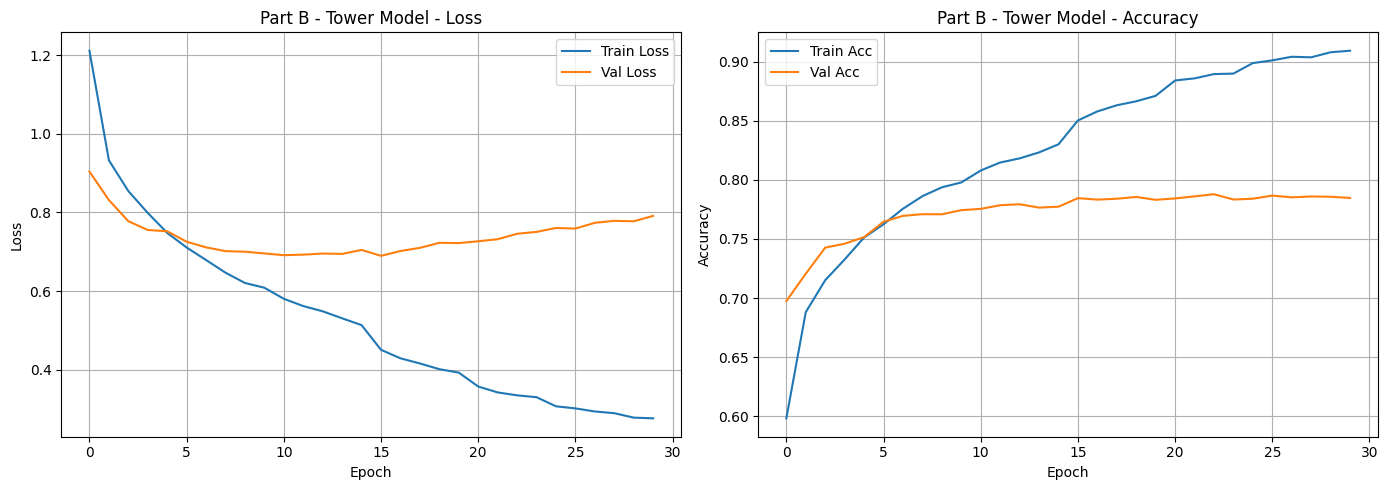

In [8]:
# ==========================================
# PART B: TOWER MODEL
# ==========================================

class TowerMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(TowerMLP, self).__init__()
        # build layers in a list
        layers = []
        # first layer: 784 -> 256
        layers.append(nn.Linear(input_size, 256))
        layers.append(nn.BatchNorm1d(256))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(0.15))

        # 5 more hidden layers: 256 -> 256
        for i in range(5):
            layers.append(nn.Linear(256, 256))
            layers.append(nn.BatchNorm1d(256))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.15))

        # output layer
        layers.append(nn.Linear(256, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(-1, 784)
        return self.network(x)

tower = TowerMLP()
tower_params = count_params(tower)
print(f'Tower parameters: {tower_params:,}')

tower_history = train_model(
    tower, train_loader, val_loader,
    epochs=30, lr=0.001, weight_decay=1e-4,
    model_name='tower'
)
plot_history(tower_history, title='Part B - Tower Model')


## Part C: The Champion (Best Architecture)
Design choices:
- Funnel shape: 1024 -> 512 -> 512 -> 256 (balances width and depth)
- GELU activation (smoother than ReLU, avoids dead neuron problem)
- BatchNorm + graduated Dropout (higher early, lower later)
- Batch size 256, lower LR with scheduler

Champion parameters: 1,731,087
Epoch [1/35] Train Loss: 1.0914 | Train Acc: 0.6435 | Val Loss: 0.8344 | Val Acc: 0.7225 | LR: 0.000800
Epoch [2/35] Train Loss: 0.8070 | Train Acc: 0.7299 | Val Loss: 0.7611 | Val Acc: 0.7500 | LR: 0.000800
Epoch [3/35] Train Loss: 0.7087 | Train Acc: 0.7624 | Val Loss: 0.7176 | Val Acc: 0.7638 | LR: 0.000800
Epoch [4/35] Train Loss: 0.6347 | Train Acc: 0.7874 | Val Loss: 0.7041 | Val Acc: 0.7690 | LR: 0.000800
Epoch [5/35] Train Loss: 0.5841 | Train Acc: 0.8030 | Val Loss: 0.6787 | Val Acc: 0.7760 | LR: 0.000800
Epoch [6/35] Train Loss: 0.5316 | Train Acc: 0.8199 | Val Loss: 0.6972 | Val Acc: 0.7761 | LR: 0.000800
Epoch [7/35] Train Loss: 0.4958 | Train Acc: 0.8319 | Val Loss: 0.6904 | Val Acc: 0.7810 | LR: 0.000800
Epoch [8/35] Train Loss: 0.4602 | Train Acc: 0.8429 | Val Loss: 0.6714 | Val Acc: 0.7879 | LR: 0.000800
Epoch [9/35] Train Loss: 0.4275 | Train Acc: 0.8545 | Val Loss: 0.6907 | Val Acc: 0.7857 | LR: 0.000800
Epoch [10/35] Train Loss: 0.3978 

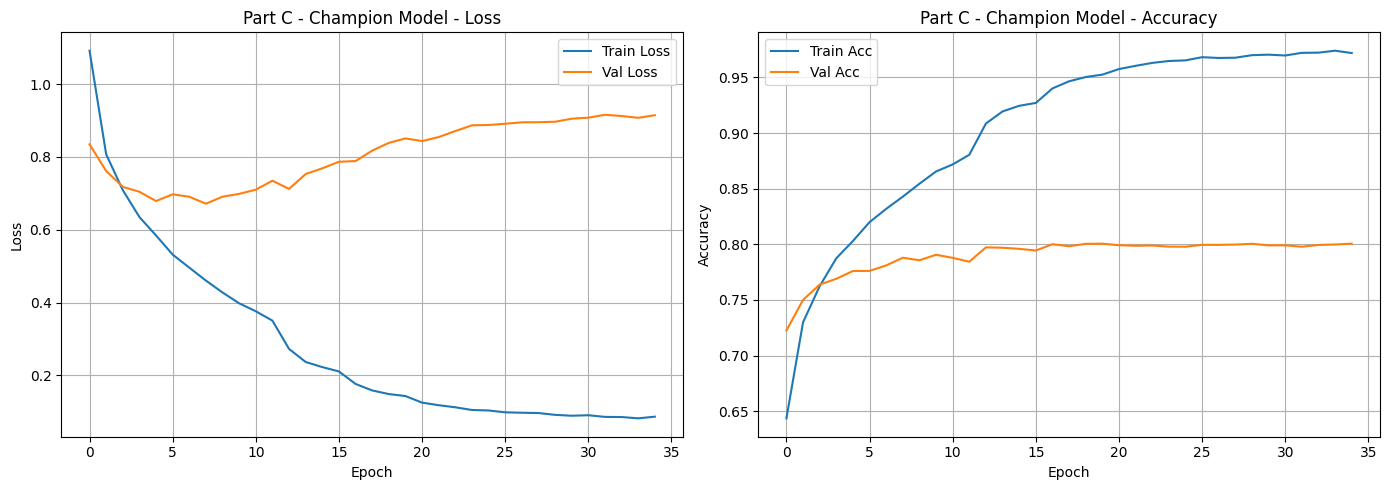

In [9]:
# ==========================================
# PART C: CHAMPION MODEL
# ==========================================

class ChampionMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(ChampionMLP, self).__init__()
        # funnel architecture: gradually narrowing
        self.fc1 = nn.Linear(input_size, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.drop1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.drop2 = nn.Dropout(0.25)

        self.fc3 = nn.Linear(512, 512)
        self.bn3 = nn.BatchNorm1d(512)
        self.drop3 = nn.Dropout(0.2)

        self.fc4 = nn.Linear(512, 256)
        self.bn4 = nn.BatchNorm1d(256)
        self.drop4 = nn.Dropout(0.15)

        self.fc_out = nn.Linear(256, num_classes)
        self.gelu = nn.GELU()

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.drop1(self.gelu(self.bn1(self.fc1(x))))
        x = self.drop2(self.gelu(self.bn2(self.fc2(x))))
        x = self.drop3(self.gelu(self.bn3(self.fc3(x))))
        x = self.drop4(self.gelu(self.bn4(self.fc4(x))))
        x = self.fc_out(x)
        return x

champion = ChampionMLP()
champion_params = count_params(champion)
print(f'Champion parameters: {champion_params:,}')

# use slightly bigger batch size and lower lr for champion
train_loader_c = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader_c = DataLoader(val_dataset, batch_size=256, shuffle=False)

champion_history = train_model(
    champion, train_loader_c, val_loader_c,
    epochs=35, lr=0.0008, weight_decay=1e-4,
    model_name='champion'
)
plot_history(champion_history, title='Part C - Champion Model')

# THIS IS THE MODEL USED FOR SUBMISSION (cells below reference 'model')
model = champion


## Part D: Theoretical Analysis
### D1: Width vs Depth
### D2: Confusion Matrix & Most Confused Pairs

--- D1: Width vs Depth ---
Pancake (wide, 2 layers):  1,868,815 params | Best Val Acc: 0.7810
Tower (deep, 6 layers):    536,847 params  | Best Val Acc: 0.7879
Champion (balanced):       1,731,087 params | Best Val Acc: 0.8006


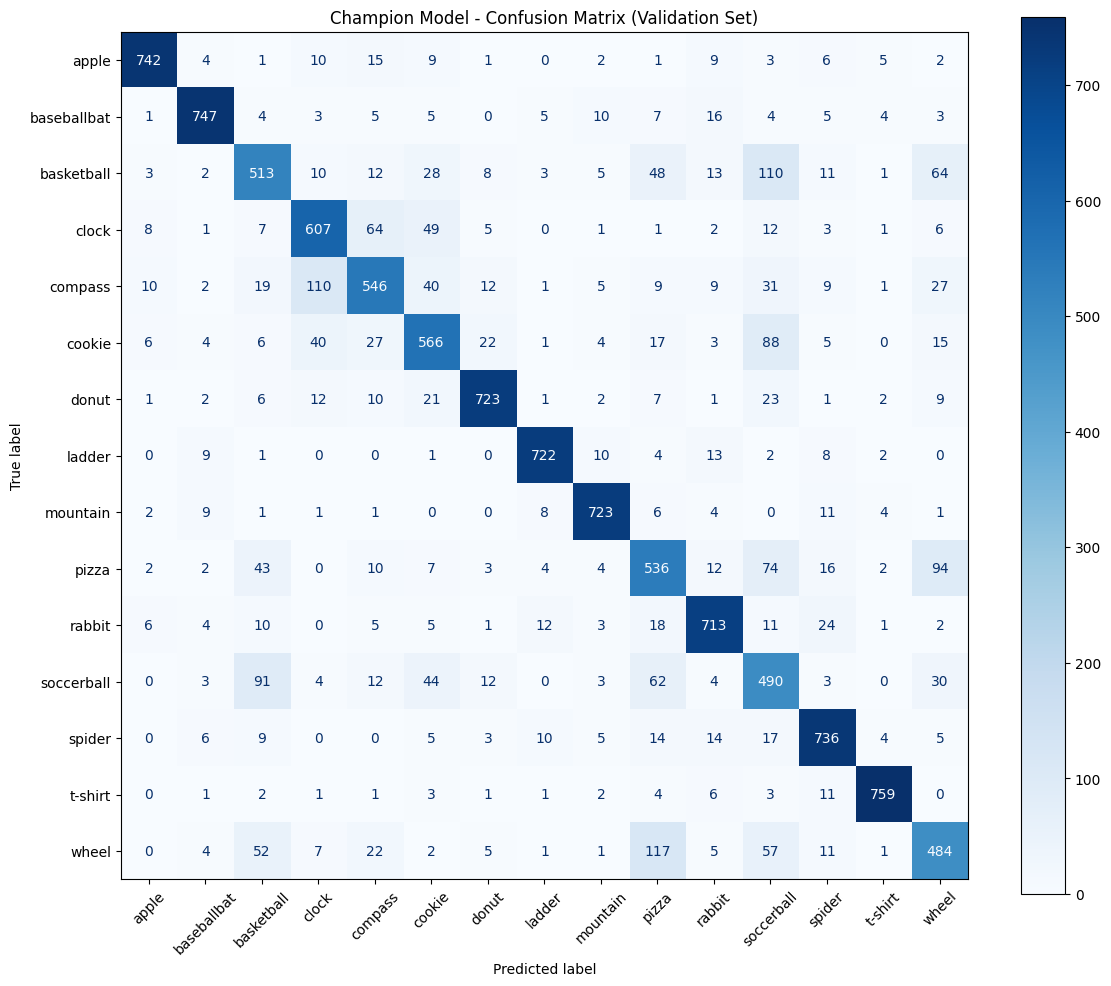


Top 5 most confused class pairs:
  pizza <-> wheel: 211 misclassifications
  basketball <-> soccerball: 201 misclassifications
  clock <-> compass: 174 misclassifications
  pizza <-> soccerball: 136 misclassifications
  cookie <-> soccerball: 132 misclassifications


In [10]:
# ==========================================
# PART D: ANALYSIS
# ==========================================

# D1: parameter and accuracy comparison
print('--- D1: Width vs Depth ---')
print(f'Pancake (wide, 2 layers):  {pancake_params:,} params | Best Val Acc: {max(pancake_history["val_acc"]):.4f}')
print(f'Tower (deep, 6 layers):    {tower_params:,} params  | Best Val Acc: {max(tower_history["val_acc"]):.4f}')
print(f'Champion (balanced):       {champion_params:,} params | Best Val Acc: {max(champion_history["val_acc"]):.4f}')

# D2: confusion matrix for champion
champion.eval()
champion.to(DEVICE)

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader_c:
        X_batch = X_batch.to(DEVICE)
        outputs = champion(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title('Champion Model - Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()

# find most confused pairs
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)

confusion_pairs = []
for i in range(len(CLASSES)):
    for j in range(i+1, len(CLASSES)):
        mutual = cm_copy[i, j] + cm_copy[j, i]
        confusion_pairs.append((mutual, CLASSES[i], CLASSES[j]))

confusion_pairs.sort(reverse=True)
print('\nTop 5 most confused class pairs:')
for count, c1, c2 in confusion_pairs[:5]:
    print(f'  {c1} <-> {c2}: {count} misclassifications')


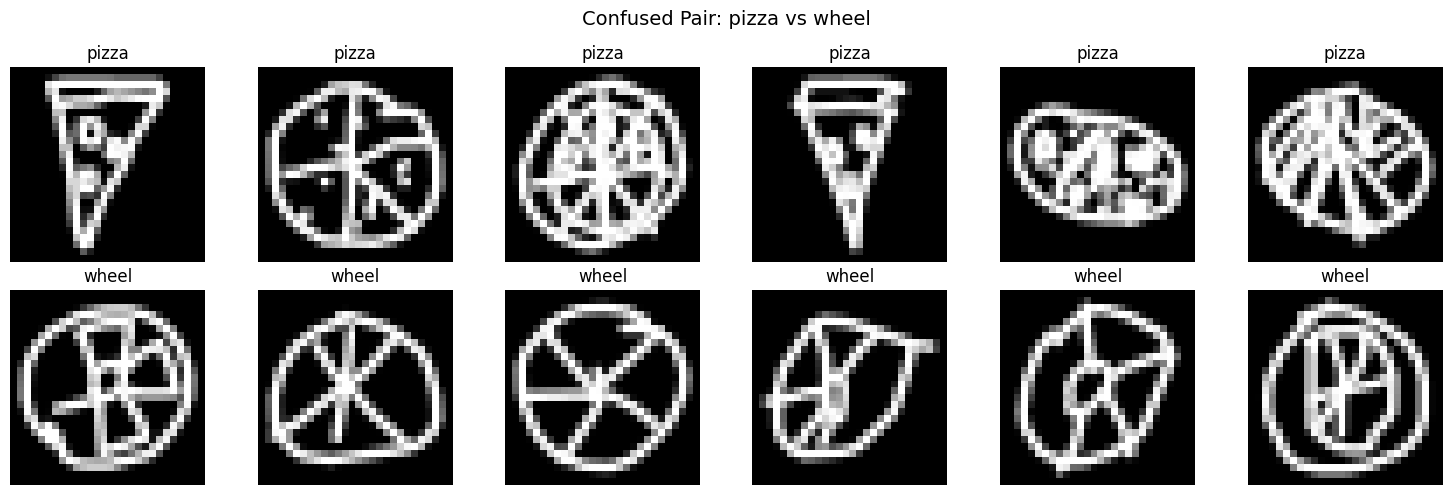

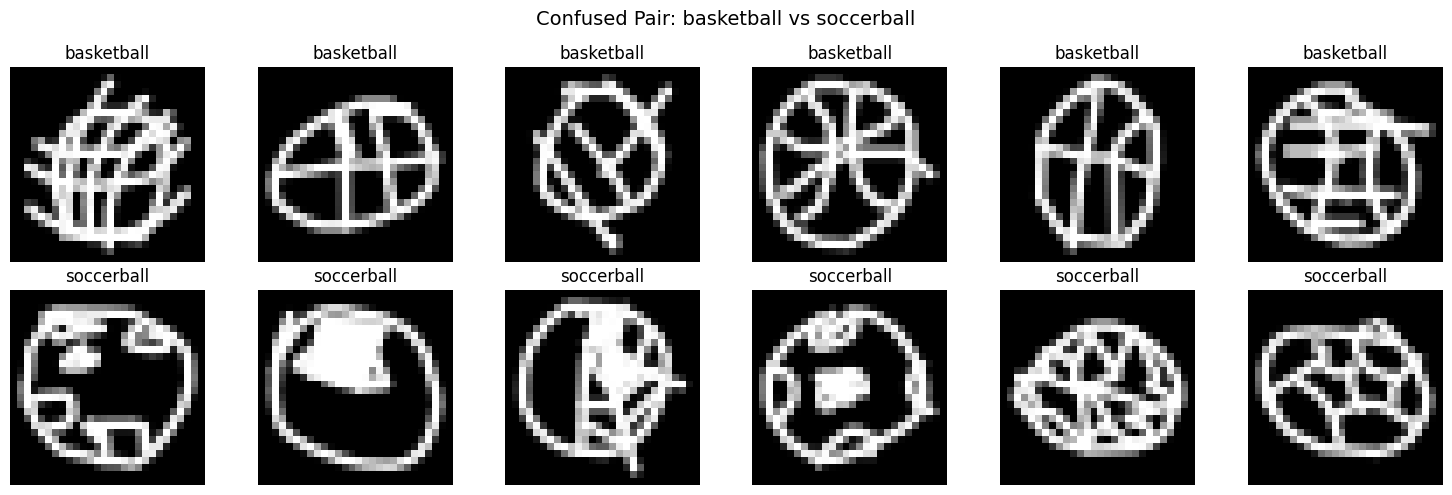

In [11]:
# visualize samples from top 2 confused pairs
def show_confused_samples(class1, class2, n_samples=6):
    idx1 = CLASSES.index(class1)
    idx2 = CLASSES.index(class2)

    all_x = full_train_dataset.x
    all_y = full_train_dataset.y

    samples1 = all_x[all_y == idx1][:n_samples]
    samples2 = all_x[all_y == idx2][:n_samples]

    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 2.5, 5))
    fig.suptitle(f'Confused Pair: {class1} vs {class2}', fontsize=14)

    for i in range(n_samples):
        axes[0, i].imshow(samples1[i].reshape(28, 28), cmap='gray')
        axes[0, i].set_title(class1)
        axes[0, i].axis('off')
        axes[1, i].imshow(samples2[i].reshape(28, 28), cmap='gray')
        axes[1, i].set_title(class2)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# top 2 confused pairs
_, c1, c2 = confusion_pairs[0]
show_confused_samples(c1, c2)
_, c1, c2 = confusion_pairs[1]
show_confused_samples(c1, c2)


## Part E: Report & Comparison

Model           Parameters      Epochs     Best Val Acc   
-------------------------------------------------------
Pancake         1,868,815       25         0.7810         
Tower           536,847         30         0.7879         
Champion        1,731,087       35         0.8006         


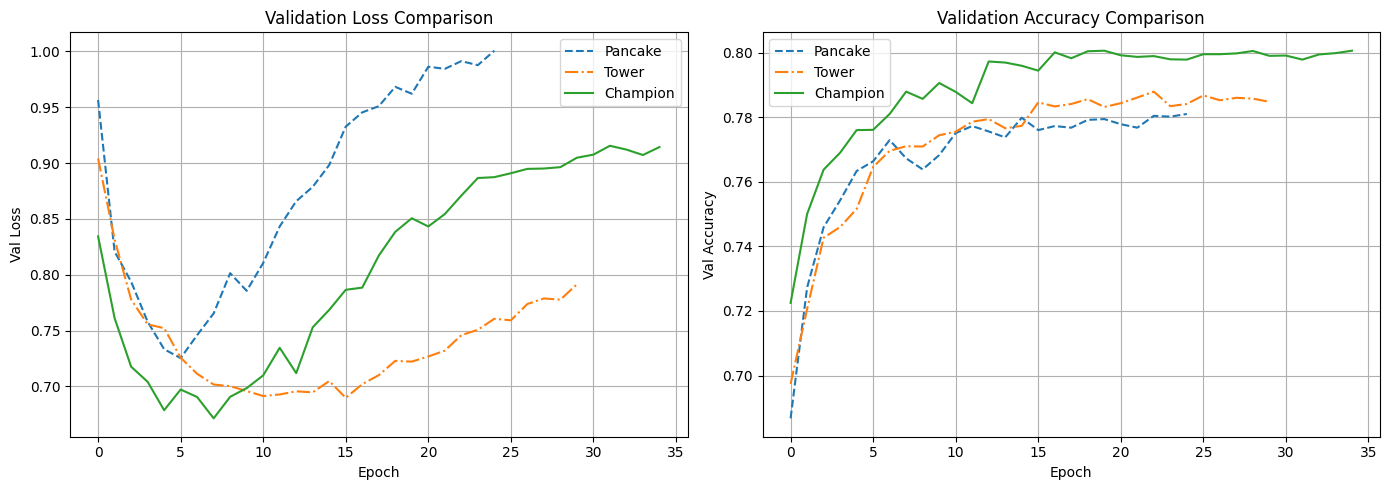

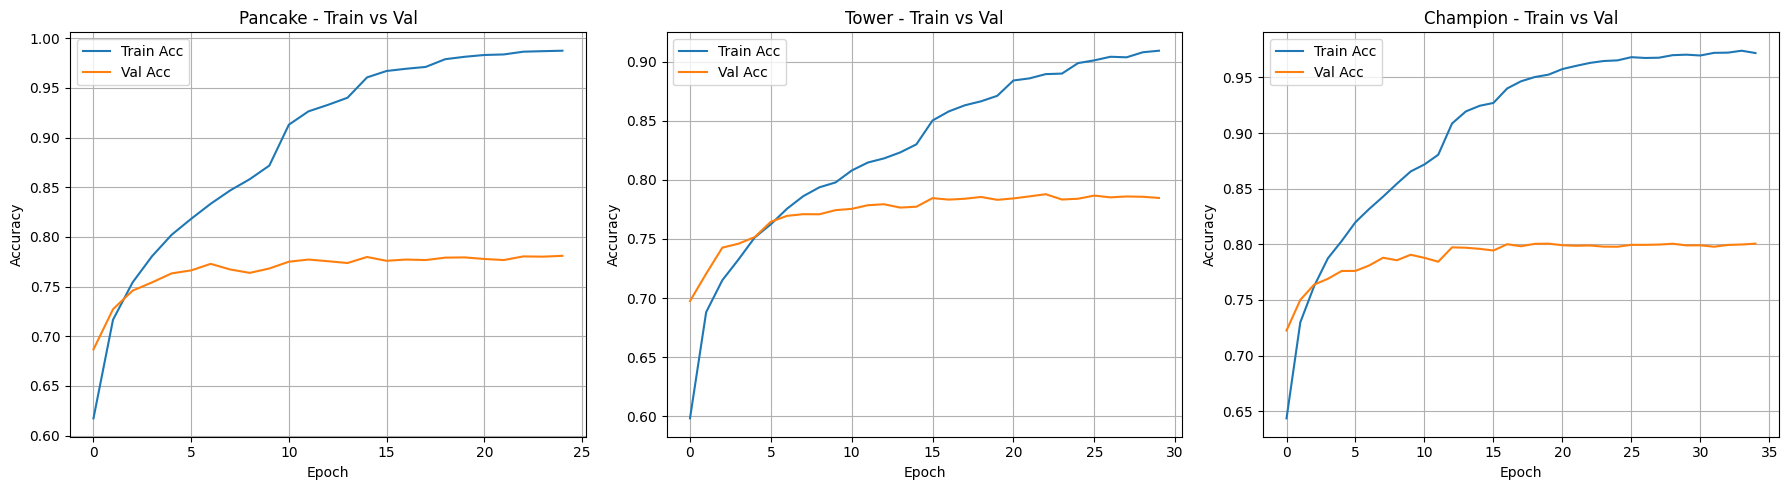

In [12]:
# ==========================================
# PART E: MODEL COMPARISON
# ==========================================

# comparison table
print(f'{"Model":<15} {"Parameters":<15} {"Epochs":<10} {"Best Val Acc":<15}')
print('-' * 55)
print(f'{"Pancake":<15} {pancake_params:<15,} {25:<10} {max(pancake_history["val_acc"]):<15.4f}')
print(f'{"Tower":<15} {tower_params:<15,} {30:<10} {max(tower_history["val_acc"]):<15.4f}')
print(f'{"Champion":<15} {champion_params:<15,} {35:<10} {max(champion_history["val_acc"]):<15.4f}')

# overlay val accuracy comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(pancake_history['val_loss'], label='Pancake', linestyle='--')
ax1.plot(tower_history['val_loss'], label='Tower', linestyle='-.')
ax1.plot(champion_history['val_loss'], label='Champion', linestyle='-')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val Loss')
ax1.set_title('Validation Loss Comparison')
ax1.legend(); ax1.grid(True)

ax2.plot(pancake_history['val_acc'], label='Pancake', linestyle='--')
ax2.plot(tower_history['val_acc'], label='Tower', linestyle='-.')
ax2.plot(champion_history['val_acc'], label='Champion', linestyle='-')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Accuracy')
ax2.set_title('Validation Accuracy Comparison')
ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()

# train vs val per model (overfitting check)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, hist, name in zip(axes,
    [pancake_history, tower_history, champion_history],
    ['Pancake', 'Tower', 'Champion']):
    ax.plot(hist['train_acc'], label='Train Acc')
    ax.plot(hist['val_acc'], label='Val Acc')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.set_title(f'{name} - Train vs Val')
    ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()


In [20]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from /content/drive/MyDrive/processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [16]:
# ==========================================
# ATTEMPT 2: BETTER MODEL + TRAINING
# ==========================================

class BetterMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(BetterMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.drop1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.drop2 = nn.Dropout(0.25)

        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.drop3 = nn.Dropout(0.2)

        self.fc4 = nn.Linear(256, 128)
        self.bn4 = nn.BatchNorm1d(128)
        self.drop4 = nn.Dropout(0.15)

        self.fc_out = nn.Linear(128, num_classes)
        self.gelu = nn.GELU()

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.drop1(self.gelu(self.bn1(self.fc1(x))))
        x = self.drop2(self.gelu(self.bn2(self.fc2(x))))
        x = self.drop3(self.gelu(self.bn3(self.fc3(x))))
        x = self.drop4(self.gelu(self.bn4(self.fc4(x))))
        x = self.fc_out(x)
        return x

better = BetterMLP()
print(f'Parameters: {count_params(better):,}')

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(better.parameters(), lr=0.002, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)

better.to(DEVICE)
best_val_acc = 0.0

train_loader_v2 = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader_v2 = DataLoader(val_dataset, batch_size=128, shuffle=False)

for epoch in range(30):
    better.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader_v2:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = better(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    scheduler.step()

    better.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader_v2:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = better(X_batch)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_acc = val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(better.state_dict(), 'better_best.pth')

    print(f'Epoch [{epoch+1}/30] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

better.load_state_dict(torch.load('better_best.pth'))
print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

# THIS LINE IS IMPORTANT - connects to the inference cell below
model = better

Parameters: 1,498,639
Epoch [1/30] Train Loss: 1.4611 | Train Acc: 0.6329 | Val Acc: 0.7166
Epoch [2/30] Train Loss: 1.2439 | Train Acc: 0.7190 | Val Acc: 0.7348
Epoch [3/30] Train Loss: 1.1643 | Train Acc: 0.7550 | Val Acc: 0.7602
Epoch [4/30] Train Loss: 1.1033 | Train Acc: 0.7800 | Val Acc: 0.7679
Epoch [5/30] Train Loss: 1.0499 | Train Acc: 0.8042 | Val Acc: 0.7783
Epoch [6/30] Train Loss: 1.0012 | Train Acc: 0.8261 | Val Acc: 0.7866
Epoch [7/30] Train Loss: 0.9626 | Train Acc: 0.8412 | Val Acc: 0.7869
Epoch [8/30] Train Loss: 0.9256 | Train Acc: 0.8582 | Val Acc: 0.7883
Epoch [9/30] Train Loss: 0.8889 | Train Acc: 0.8740 | Val Acc: 0.7870
Epoch [10/30] Train Loss: 0.8552 | Train Acc: 0.8890 | Val Acc: 0.7911
Epoch [11/30] Train Loss: 0.8233 | Train Acc: 0.9027 | Val Acc: 0.7915
Epoch [12/30] Train Loss: 0.7993 | Train Acc: 0.9135 | Val Acc: 0.7914
Epoch [13/30] Train Loss: 0.7726 | Train Acc: 0.9251 | Val Acc: 0.7883
Epoch [14/30] Train Loss: 0.7479 | Train Acc: 0.9363 | Val Acc: 

In [ ]:
# ==========================================
# FINAL ATTEMPT: SKIP CONNECTIONS + BATCH 64
# ==========================================
from torch.optim.swa_utils import AveragedModel, SWALR

class ResBlock(nn.Module):
    """Residual block: x + f(x) helps gradient flow."""
    def __init__(self, dim, dropout=0.3):
        super(ResBlock, self).__init__()
        self.fc = nn.Linear(dim, dim)
        self.bn = nn.BatchNorm1d(dim)
        self.gelu = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return x + self.drop(self.gelu(self.bn(self.fc(x))))

class FinalMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(FinalMLP, self).__init__()
        # input projection
        self.input_layer = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4)
        )
        # residual blocks at 512 dim (skip connections!)
        self.res1 = ResBlock(512, dropout=0.35)
        self.res2 = ResBlock(512, dropout=0.3)
        self.res3 = ResBlock(512, dropout=0.25)

        # output projection
        self.output_layer = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

        # kaiming init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.input_layer(x)
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        x = self.output_layer(x)
        return x

# 90/10 split
train_size_f = int(0.90 * len(full_train_dataset))
val_size_f = len(full_train_dataset) - train_size_f
train_ds_f, val_ds_f = random_split(
    full_train_dataset, [train_size_f, val_size_f],
    generator=torch.Generator().manual_seed(42)
)

# BATCH SIZE 64 - teacher hinted at this, more noise = less overfitting
train_loader_f = DataLoader(train_ds_f, batch_size=64, shuffle=True)
val_loader_f = DataLoader(val_ds_f, batch_size=256, shuffle=False)

best_overall_acc = 0.0
best_model_state = None
best_seed = None

for seed in [42, 99, 123, 456, 777, 888, 999]:
    torch.manual_seed(seed)
    np.random.seed(seed)

    m = FinalMLP().to(DEVICE)
    TOTAL_EPOCHS = 25
    SWA_START = 18

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(m.parameters(), lr=0.002, weight_decay=2e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=8, T_mult=1, eta_min=1e-5
    )
    swa_model = AveragedModel(m)
    swa_scheduler = SWALR(optimizer, swa_lr=0.0005)

    best_val_acc = 0.0

    for epoch in range(TOTAL_EPOCHS):
        m.train()
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader_f:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = m(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_acc = correct / total

        if epoch >= SWA_START:
            swa_model.update_parameters(m)
            swa_scheduler.step()
        else:
            scheduler.step()

        m.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader_f:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                outputs = m(X_batch)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == y_batch).sum().item()
                val_total += y_batch.size(0)
        val_acc = val_correct / val_total

        if val_acc > best_val_acc:
            best_val_acc = val_acc

    # check SWA model
    torch.optim.swa_utils.update_bn(train_loader_f, swa_model, device=DEVICE)
    swa_model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader_f:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = swa_model(X_batch)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == y_batch).sum().item()
            val_total += y_batch.size(0)
    swa_acc = val_correct / val_total

    final_acc = max(best_val_acc, swa_acc)
    use_swa = swa_acc >= best_val_acc

    print(f'Seed {seed}: Val {best_val_acc:.4f} | SWA {swa_acc:.4f} | Best {final_acc:.4f} {"[SWA]" if use_swa else ""}')

    if final_acc > best_overall_acc:
        best_overall_acc = final_acc
        best_seed = seed
        if use_swa:
            best_model_state = swa_model.module.state_dict().copy()
        else:
            best_model_state = m.state_dict().copy()

print(f'\n=== BEST: seed {best_seed}, Acc: {best_overall_acc:.4f} ===')

final_model = FinalMLP().to(DEVICE)
final_model.load_state_dict(best_model_state)
model = final_model
print(f'Parameters: {count_params(model):,}')

In [14]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 1,731,087
  ✅ Parameter count is within limits.


In [15]:
# Option 1: Print predictions so you can copy them directly
predictions = get_predictions(model, test_loader)
submission_string = ",".join(map(str, predictions))

print(f"Total predictions: {len(predictions)}")
print()
print("--- COPY EVERYTHING BELOW THIS LINE ---")
print(submission_string)
print("--- COPY EVERYTHING ABOVE THIS LINE ---")

# Option 2: Also save to Google Drive so you don't lose it
with open("/content/drive/MyDrive/submission.txt", "w") as f:
    f.write(submission_string)
print("\nAlso saved to Google Drive: /MyDrive/submission.txt")

Total predictions: 15000

--- COPY EVERYTHING BELOW THIS LINE ---
6,11,5,5,0,1,11,9,14,8,9,7,11,11,13,8,13,12,11,5,13,6,14,8,0,13,13,2,6,5,9,11,1,12,13,5,14,5,8,2,12,8,0,2,13,1,11,9,10,1,5,11,0,11,3,11,11,6,10,2,9,6,7,11,0,12,11,12,3,11,3,6,3,9,0,6,5,6,2,11,10,13,6,4,12,0,0,2,9,11,0,7,1,14,5,6,5,12,9,10,14,10,1,4,5,9,7,3,14,11,9,1,7,13,12,2,1,7,9,0,4,7,9,2,13,13,7,9,3,4,5,6,0,8,9,11,5,12,1,13,10,2,1,14,1,12,7,11,3,0,14,14,1,12,6,7,0,2,9,6,0,9,5,13,9,13,5,11,1,5,12,10,4,4,13,7,14,11,7,11,2,13,10,3,12,3,8,6,2,1,14,9,8,6,0,4,1,5,5,2,6,14,10,1,13,1,1,10,5,7,14,5,1,9,6,2,6,3,8,1,0,4,7,12,9,11,13,14,3,0,11,6,4,14,1,3,12,0,9,4,9,11,4,12,4,9,5,0,5,7,6,5,7,1,13,5,1,9,0,5,13,0,7,3,6,3,12,12,3,7,13,11,11,3,10,8,12,8,6,6,1,7,12,12,0,3,9,4,12,4,6,6,2,0,9,12,11,6,3,1,5,12,3,0,6,11,11,7,13,8,12,13,9,1,5,5,14,10,14,13,0,9,11,11,7,9,3,10,11,12,13,9,6,3,14,14,7,8,10,1,14,10,2,1,10,14,12,14,0,7,7,0,5,7,11,7,12,1,7,12,2,13,4,11,5,14,11,8,7,11,12,2,4,13,1,9,4,1,0,13,9,3,10,14,6,0,4,4,10,2,4,5,14,11,3,11,13

In [21]:
# print predictions for easy copy-paste
predictions = get_predictions(model, test_loader)
submission_string = ",".join(map(str, predictions))
print(f"Total predictions: {len(predictions)}")
print()
print("--- COPY BELOW ---")
print(submission_string)
print("--- COPY ABOVE ---")

# save to drive too
with open("/content/drive/MyDrive/submission_v3.txt", "w") as f:
    f.write(submission_string)
print("\nSaved to Drive!")

Total predictions: 15000

--- COPY BELOW ---
6,11,5,5,0,1,11,9,14,8,9,7,11,11,13,8,13,12,11,5,13,6,14,8,0,13,13,2,6,5,14,4,1,12,13,5,14,5,8,2,12,8,0,2,13,1,11,9,10,1,5,11,0,11,13,11,11,6,10,2,9,6,7,2,0,12,4,12,4,2,3,6,3,14,13,6,5,6,2,11,10,13,6,4,12,0,0,11,2,11,0,7,1,14,5,6,3,12,9,10,14,12,1,5,5,9,7,4,11,11,9,1,1,13,12,2,1,7,11,0,4,7,14,2,13,13,7,14,3,4,5,6,0,8,9,11,3,12,1,13,10,11,1,14,1,12,7,11,3,0,2,14,1,12,6,0,0,2,9,6,0,9,5,13,9,13,5,5,1,5,12,10,4,4,13,7,14,6,7,11,2,13,10,3,12,3,8,6,2,1,14,9,8,5,0,4,1,5,5,2,6,14,10,1,13,1,1,10,5,7,14,11,1,11,6,2,6,3,8,1,12,4,7,12,9,11,13,14,4,0,11,6,4,14,1,4,10,0,5,4,9,2,4,12,4,9,5,0,6,7,6,5,7,1,13,5,1,9,0,4,13,0,7,0,6,3,12,12,3,7,13,11,11,3,0,8,12,8,6,6,1,7,12,8,0,3,9,4,12,6,6,6,2,0,9,12,11,6,3,1,5,12,3,0,6,11,11,7,13,8,12,13,9,1,5,5,14,10,14,13,0,9,8,11,7,9,3,10,11,12,13,13,6,3,11,14,7,8,10,1,9,10,2,1,10,14,12,14,0,7,7,0,2,7,11,7,12,1,7,12,2,13,4,11,5,14,11,8,7,11,12,11,4,13,1,14,4,10,0,13,11,3,10,9,6,0,4,4,10,2,4,5,14,11,3,11,13,10,3,13,9,3,8,7,